In [1]:
import math

import torch
from omegaconf import OmegaConf
import matplotlib.pyplot as plt

from icl import LowRankTransformer, get_triggers, get_distributions, generate_dual_task_batch, Evaluator, LossMetric, initialize_model, DualModel
from icl.evaluation.scalar_probes import M2, Eta2

In [3]:
model_args = OmegaConf.structured({
    'vocab_size' : 16,
    'seq_len' : 16,
    'd_model' : 2048,
    'rank' : 32,
    'dropout' : 0.0,
    'lin_attn' : True,
    'beta' : 0.5
})


data_args = OmegaConf.structured({
    'b_type' : 'spiked',
    'alpha_d' : 0.1,
    'alpha_z' : 1.0,
    'u_type' : 'uniform',
    'beta' : 0.0,
    'fix_trig' : 'rand',
    'K' : 10,
    'trig_type': 'freq',
    'batch_size' : 5
})

# Define loss and optimizer
loss_fn = torch.nn.CrossEntropyLoss()

In [ ]:
# Make a mask for the sub-diagonal of a matrix
L = 5
mask_sub_diagonal = torch.tril(torch.ones((L, L)), diagonal=-1).bool()
print(mask_sub_diagonal)

tensor([[False, False, False, False, False],
        [ True, False, False, False, False],
        [ True,  True, False, False, False],
        [ True,  True,  True, False, False],
        [ True,  True,  True,  True, False]])


In [4]:
model = LowRankTransformer(model_args)
# model = DualModel(model_args)
model = initialize_model(model,path='induction',sigma_0=1.0)
distributions = get_distributions(data_args,model_args.vocab_size)
trigger_set = get_triggers(data_args, distributions['P_t'])
batch = generate_dual_task_batch(data_args.batch_size,
                                 model_args.seq_len,
                                 data_args.K,
                                 distributions,
                                 trigger_set)

for k , v in batch.items():
    print(k,v.shape)

Generating spiked bigram distribution with and beta =  0.0
Generating unigram distribution from a uniform distribution
Using fixed freq trigger set
Length of trigger set: 10, Trigger set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
sequence torch.Size([5, 17])
trigger_set torch.Size([5, 10])
output_set torch.Size([5, 10])
counts torch.Size([5, 16])
is_trigg torch.Size([5, 16])
mask torch.Size([5, 16, 16])


In [5]:
metrics = [LossMetric(name='loss',
                      logits_fn=lambda ctx:ctx.logits_induction[ctx.all],
                      target_fn=lambda ctx:ctx.target[ctx.all],
                      rescale=False),
            M2(),
            Eta2(),
                      ]
evaluator = Evaluator(metrics)
res = evaluator.evaluate(model, batch, loss_fn, distributions['P_b'], distributions['P_u'])

for k,v in res.items():
    print(k,v)

sequence = batch['sequence'] # shape (batch_size, seq_len + 1)
input = sequence[:, :-1].clone() # shape (batch_size, seq_len)
target = sequence[:, 1:].clone() # shape (batch_size, seq_len)
mask = batch['mask'] # shape (batch_size, seq_len, seq_len)
counts = batch['counts'] # shape (batch_size, seq_len)
trigg_set = batch['trigger_set'] # shape (batch_size, K)

output = model.full_output(input, mask, path='induction')

s2 = output['S2']
print('S2 shape:', s2.shape)
print('S2_std =', s2.std().item())

loss 2.7721407413482666
m2 -0.1362831517489918
eta2 0.4976339938080084
S2 shape: torch.Size([5, 16, 16])
S2_std = 0.6658653020858765


In [6]:
sequence = batch['sequence'] # shape (batch_size, seq_len + 1)
input = sequence[:, :-1].clone() # shape (batch_size, seq_len)
target = sequence[:, 1:].clone() # shape (batch_size, seq_len)
mask = batch['mask'] # shape (batch_size, seq_len, seq_len)
counts = batch['counts'] # shape (batch_size, seq_len)
trigg_set = batch['trigger_set'] # shape (batch_size, K)

output = model.full_output(input, mask, path='induction')
logits = output['logits']
print(logits.shape)
loss = loss_fn(logits.view(-1,model_args.vocab_size),target.view(-1))

for k, v in output.items():
    print(k,v.shape)

print(f'Flat output loss = {math.log(model_args.vocab_size)}')
print(f"Evaluation Loss = {loss.item()}")


torch.Size([5, 16, 16])
X0 torch.Size([5, 16, 2048])
X1 torch.Size([5, 16, 2048])
A1 torch.Size([5, 16, 16])
S1 torch.Size([5, 16, 16])
X2 torch.Size([5, 16, 2048])
A2 torch.Size([5, 16, 16])
S2 torch.Size([5, 16, 16])
X3 torch.Size([5, 16, 2048])
logits torch.Size([5, 16, 16])
Flat output loss = 2.772588722239781
Evaluation Loss = 2.7721407413482666


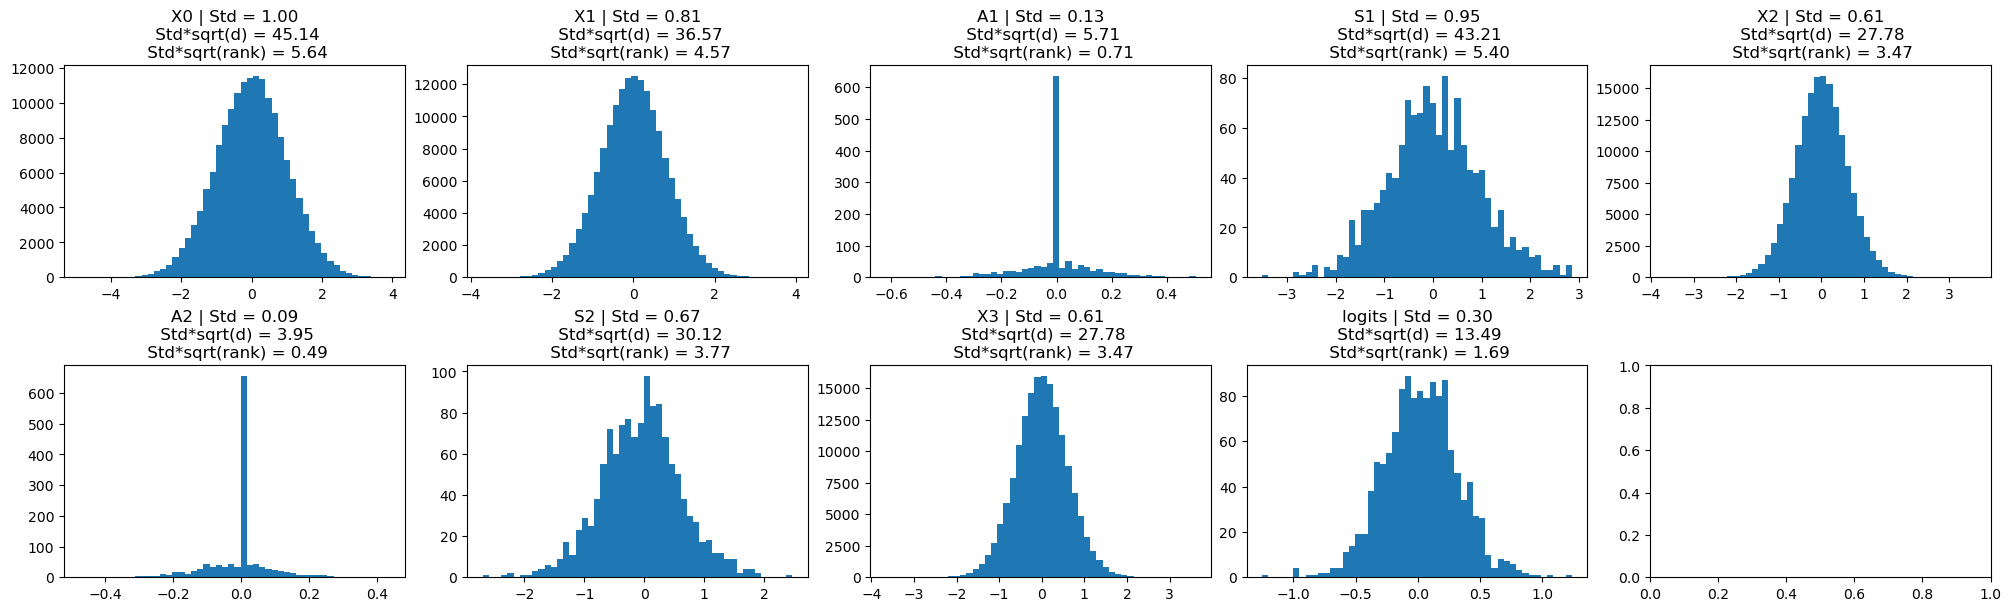

In [7]:
# U = model.unembed.U.weight.detach().numpy()
ncols = 5
nrows = math.ceil(len(output)/ncols)
fig , axes = plt.subplots(nrows,ncols, figsize=(ncols*4,nrows*3),layout='constrained')
keys = list(output.keys()) 
axes = axes.flatten()
for i , key in enumerate(keys):
    ax = axes[i]
    W = output[key].detach().numpy().flatten()
    ax.hist(W, bins=50)
    ax.set_title(key)
    ax.set_title(f"{key} | Std = {W.std():.2f}\n Std*sqrt(d) = {W.std()*math.sqrt(model.d_model):.2f}\n Std*sqrt(rank) = {W.std()*math.sqrt(model_args.rank):.2f}")
    

In [8]:
names = []
for name in model.state_dict():
    names.append(name)
    print(name,' | ', model.state_dict()[name].shape)
print(names)

embed.E.weight  |  torch.Size([16, 2048])
embed.P.weight  |  torch.Size([16, 2048])
attn1.WQ.weight  |  torch.Size([32, 2048])
attn1.WK.weight  |  torch.Size([32, 2048])
attn1.WV.weight  |  torch.Size([32, 2048])
attn1.WO.weight  |  torch.Size([2048, 32])
attn2.WQ.weight  |  torch.Size([32, 2048])
attn2.WK.weight  |  torch.Size([32, 2048])
attn2.WV.weight  |  torch.Size([32, 2048])
attn2.WO.weight  |  torch.Size([2048, 32])
ff.WF_down.weight  |  torch.Size([32, 2048])
ff.WF_up.weight  |  torch.Size([2048, 32])
unembed.U.weight  |  torch.Size([16, 2048])
['embed.E.weight', 'embed.P.weight', 'attn1.WQ.weight', 'attn1.WK.weight', 'attn1.WV.weight', 'attn1.WO.weight', 'attn2.WQ.weight', 'attn2.WK.weight', 'attn2.WV.weight', 'attn2.WO.weight', 'ff.WF_down.weight', 'ff.WF_up.weight', 'unembed.U.weight']


In [7]:
model.d_model

1024

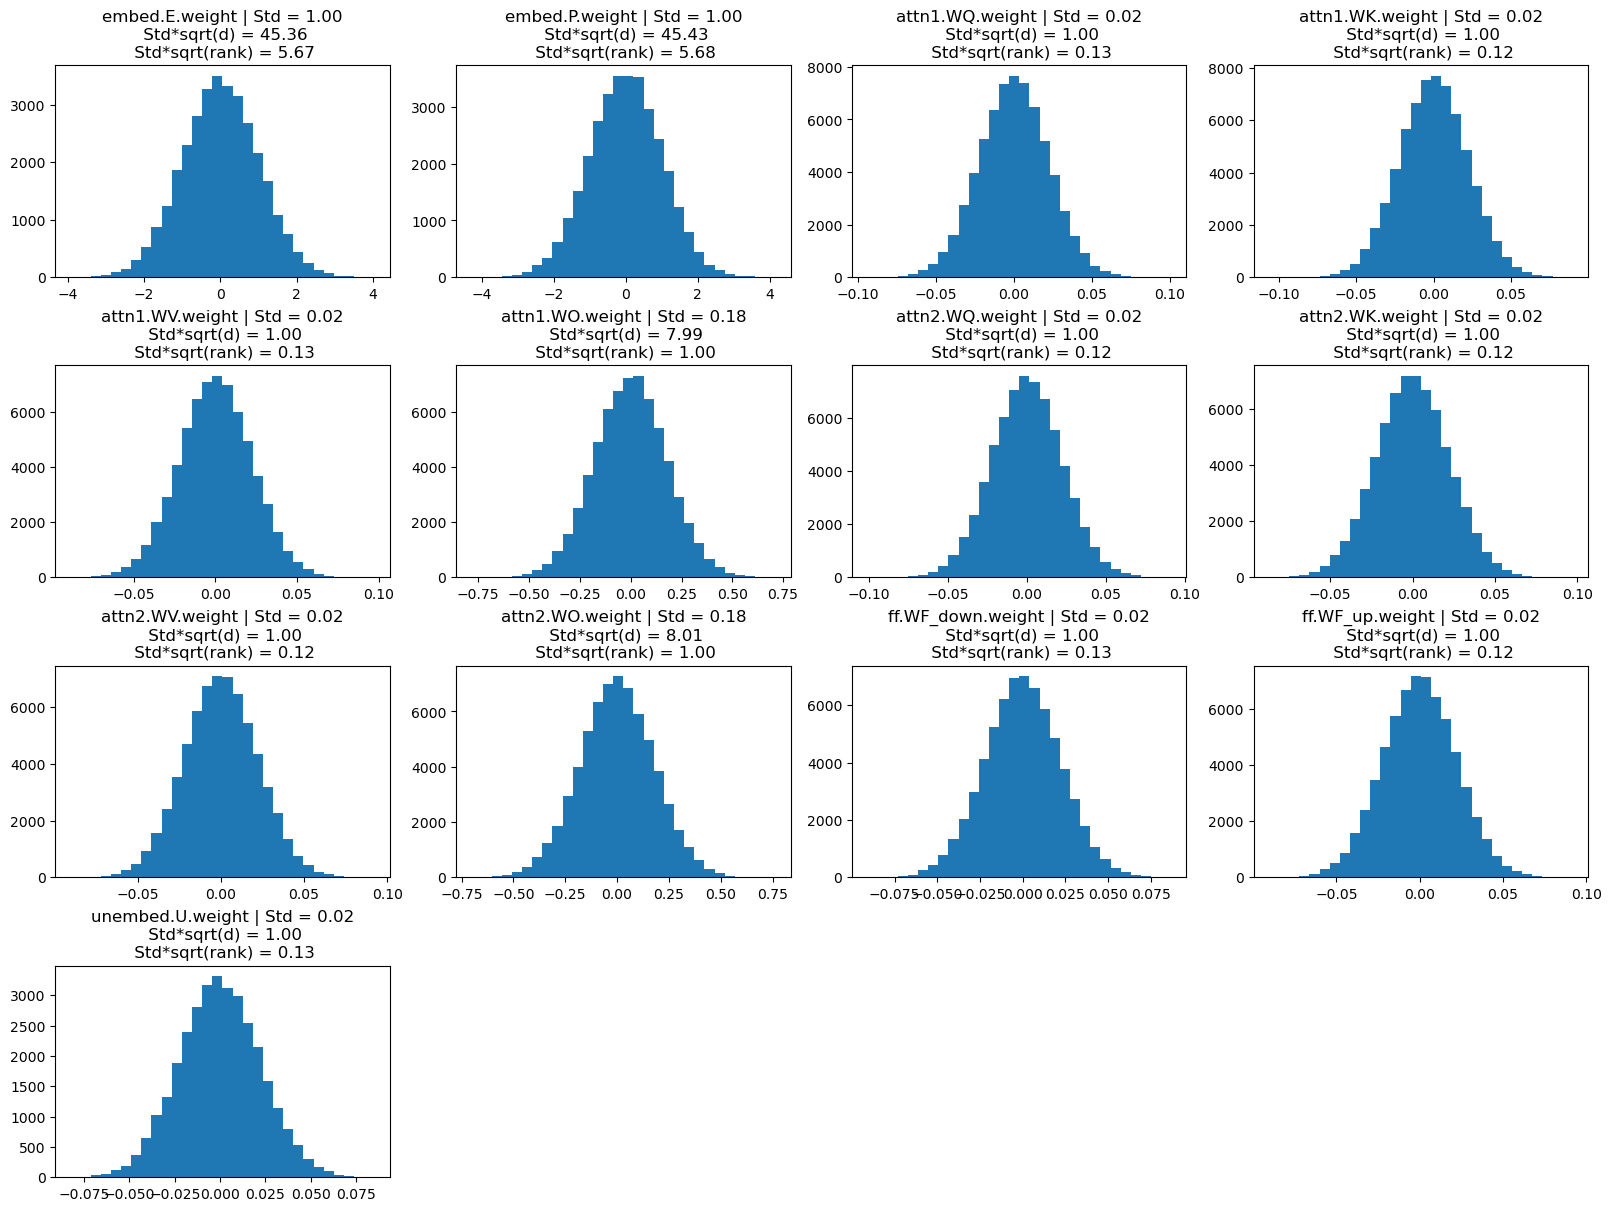

In [11]:
# U = model.unembed.U.weight.detach().numpy()
ncols = 4
nrows = math.ceil(len(names)/ncols)
fig , axes = plt.subplots(nrows,ncols, figsize=(ncols*4,nrows*3),layout='constrained')

for i , ax in enumerate(axes.flatten()):
    if i < len(names):
        name = names[i]
        W = model.state_dict()[name].numpy()
        ax.hist(W.flatten(), bins=30)
        ax.set_title(f"{name} | Std = {W.std():.2f}\n Std*sqrt(d) = {W.std()*math.sqrt(model.d_model):.2f}\n Std*sqrt(rank) = {W.std()*math.sqrt(model_args.rank):.2f}")
    else:
        ax.axis('off')
# name = names[0]
# M = model.embed.P.weight.detach().numpy()
# plt.hist(U.flatten(), bins=30)
# plt.title("Std = {:.4f}".format(U.std()))
# plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

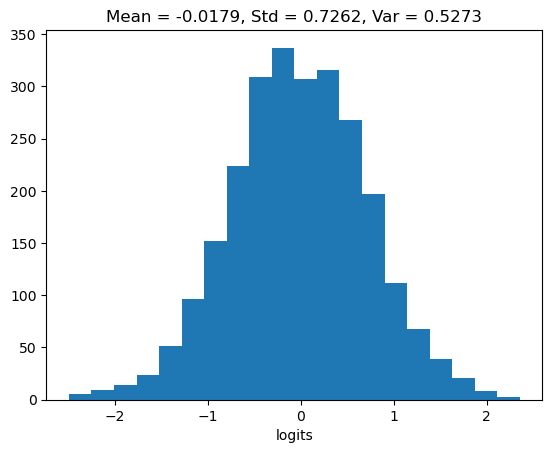

In [20]:
i_batch = 0
variable = 'logits'

var = output[variable].detach().numpy()
mean = var.mean()
std = var.std()


plt.hist(var.flatten(),bins=20)
plt.title(f'Mean = {mean:.4f}, Std = {std:.4f}, Var = {std**2:.4f}')
plt.xlabel(variable)
plt.show

loss 3.682290554046631
m -2.4899179607018596e-06
